# Doing a 1 basin LSTM


In [42]:
import xarray as xr

ds = xr.open_dataset("Caravan-nc/timeseries/netcdf/camels/camels_01013500.nc")

def add_water_year(ds):
    '''
    Water year is defined as Oct 1 to Sep 30.
    Oct, Nov, Dec are labelled as regular year + 1
    '''
    t = ds['date']
    water_year = t.dt.year + (t.dt.month >= 10)
    new_ds = ds.assign_coords(water_year=water_year)
    return new_ds

ds = add_water_year(ds)

# Get rid of NaN values
ds = ds.dropna(dim='date', 
               subset=['streamflow', 
                       'total_precipitation_sum',
                       'temperature_2m_mean',
                       'surface_net_solar_radiation_mean',
                       'surface_net_thermal_radiation_mean',
                       'dewpoint_temperature_2m_mean',
                       'u_component_of_wind_10m_mean',
                       'v_component_of_wind_10m_mean'], # From which features
                 how='any') # Any of the subsets


- LSTM definition.
- Train on all days; predict on all days; group test/train days into water years and calculate metrics from there.

In [43]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size, # the dimensionality of ct and ht
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.output = nn.Linear(hidden_size, output_size) # This is the fully connected output layer turning the h_t into an output

    def forward(self, x, state=None): # This is what happens when you call model(x); state=None means if there is no supplied LSTM state then start from scratch
        '''
        x is in Batch, Time, input size dimensions
        '''
        out, (h_n, c_n) = self.lstm(x, state)       # out is in Batch, Time, hidden_size dimensions
        y = self.output(out[:, -1, :])                  # last time step yields B, hidden which transforms into Batch, output size
        return y, (h_n, c_n)


# PyTorch dataloader needs data to be able to do certain things
from torch.utils.data import Dataset, DataLoader

class BasinDataset(Dataset):
    def __init__(self, features, streamflow, water_years, seq_len=365):
        '''
        features in time, num_features dimensional numpy array
        streamflow in time dimensional numpy array
        '''
        self.x = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(streamflow, dtype=torch.float32)
        self.seq_len = seq_len
        self.water_years = water_years

    def __len__(self): # this is one of those things dataloader needs from a dataset
        return len(self.y) - self.seq_len # There are total - 365 sequences available

    def __getitem__(self, i):
        x_seq = self.x[i : i + self.seq_len]
        y_val = self.y[i + self.seq_len]
        t_val = self.water_years[i + self.seq_len]
        return x_seq, y_val, t_val

# Define the normalised square loss for the training
def nse_loss(y_pred, y_obs, std_train):
    return torch.mean((y_pred - y_obs) ** 2) / (std_train + 1e-6) ** 2

- Now do the datasplit


In [55]:
import numpy as np

# Split by water year as in paper
last_training_year = 1999 # 20 after 1980 inclusive
last_valid_year = 2004  # 5 years 
all_water_years = np.array(ds['water_year'])
trainsplit_idx = np.searchsorted(all_water_years, last_training_year + 1e-4)
validsplit_idx = np.searchsorted(all_water_years, last_valid_year + 1e-4)
# split idx is the first datapoint of the test set

# Create the features
basin01013500_features = np.stack([
    ds['total_precipitation_sum'].values,
    ds['temperature_2m_mean'].values,
    ds['surface_net_solar_radiation_mean'].values,
    ds['surface_net_thermal_radiation_mean'].values,
    ds['dewpoint_temperature_2m_mean'].values,
    np.sqrt(ds['u_component_of_wind_10m_mean']**2 + ds['v_component_of_wind_10m_mean']**2).values
    ], axis=1)

# Split the datasets
x_train = basin01013500_features[:trainsplit_idx]
x_valid = basin01013500_features[trainsplit_idx:validsplit_idx]
x_test = basin01013500_features[validsplit_idx:]

y_train = ds['streamflow'].values[:trainsplit_idx]
y_valid = ds['streamflow'].values[trainsplit_idx:validsplit_idx]
y_test = ds['streamflow'].values[validsplit_idx:]

t_train = ds['water_year'].values[:trainsplit_idx]
t_valid = ds['water_year'].values[trainsplit_idx:validsplit_idx]
t_test = ds['water_year'].values[validsplit_idx:]


# The test and train datasets
basin01013500_trainset = BasinDataset(features=x_train,
                                       streamflow=y_train,
                                       water_years=t_train)
basin01013500_validset = BasinDataset(features=x_valid,
                                       streamflow=y_valid,
                                       water_years=t_valid)
basin01013500_testset = BasinDataset(features=x_test, 
                                     streamflow=y_test,
                                     water_years=t_test)

# Put them into dataloaders
train_loader = DataLoader(
    basin01013500_trainset,
    batch_size=256,
    shuffle=True
)

valid_loader = DataLoader(
    basin01013500_validset,
    batch_size=256,
    shuffle=False
)

test_loader = DataLoader(
    basin01013500_testset,
    batch_size=256,
    shuffle=False
)


- Training montage

In [62]:
std_train = np.std(y_train)

num_features = x_train.shape[1]
model = LSTMModel(input_size=num_features, 
                hidden_size=128,
                num_layers=1,
                output_size=1, # only the streamflow is predicted
                  )
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

best_valid_loss = float('inf')
patience = 5
epochs_no_improve = 0

train_loss_history = []
valid_loss_history = []

for epoch in range(30):
    model.train()
    for x_batch, y_batch, t_batch in train_loader:
        optimiser.zero_grad()
        y_pred, (h_n, c_n) = model(x_batch)
        loss = nse_loss(y_pred.squeeze(), y_batch, std_train=std_train)
        train_loss_history.append(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # paper clips to norm 1
        optimiser.step()

        # Evaluate on validation set
        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch, t_batch in valid_loader:
                y_pred, _ = model(x_batch)
                valid_loss += nse_loss(y_pred.squeeze(), y_batch, std_train=std_train).item()
        valid_loss /= len(valid_loader)
        valid_loss_history.append(valid_loss)
    print(f"{epoch}/30  valid_loss={valid_loss:.4f}")
    

    # Early stopping
    if valid_loss <= best_valid_loss:
        best_valid_loss = valid_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")

    else: 
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Stopping early")
            break

# Restore model
model.load_state_dict(torch.load("best_model.pt"))



0/30  valid_loss=0.6435
1/30  valid_loss=0.4953
2/30  valid_loss=0.3620
3/30  valid_loss=0.2889
4/30  valid_loss=0.2744
5/30  valid_loss=0.2608
6/30  valid_loss=0.2133
7/30  valid_loss=0.2122
8/30  valid_loss=0.1925
9/30  valid_loss=0.1907
10/30  valid_loss=0.1869
11/30  valid_loss=0.1965
12/30  valid_loss=0.1956
13/30  valid_loss=0.1958
14/30  valid_loss=0.1950
15/30  valid_loss=0.2000
Stopping early


<All keys matched successfully>

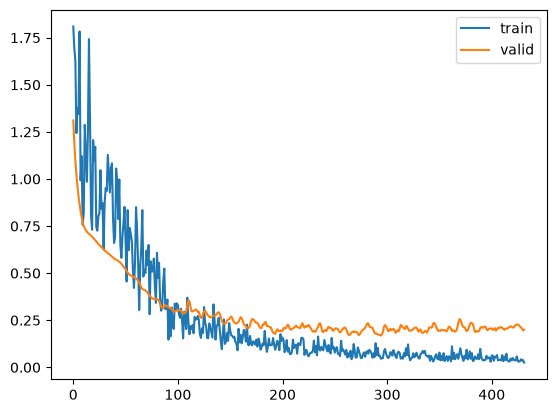

In [63]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label = 'train')
plt.plot(valid_loss_history, label = 'valid')
plt.legend()
plt.show()

- Now try with test set.